# Demonstrate mapping with pixel_table only

In [1]:
%reset -f
%run setup_notebook.py
from importlib import reload
from utilities.ipynb_docgen import show, show_date, capture_hide; show_date()
from like3 import pixel_table; reload(pixel_table)
from like3.pixel_table import PixelTable, np, plt, pd, SkyCoord
show((f""" #### Load the pixel table """))
pt = pixel_table = PixelTable('files/kerr/pixel_table_v5.fits')
plt.style.use('dark_background')
from utilities.catalogs import Fermi4FGL, DataFrameCatalog
fgl = Fermi4FGL('v40')

<h5 style="text-align:right; margin-right:15px"> 2026-09-28 10:08</h5>

#### Load the pixel table 

Loaded pixel table from "files/kerr/pixel_table_v5.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order nested
            
Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries


In [2]:
%matplotlib widget
from vscdark import set_style
set_style(dark=True, display_css=True)

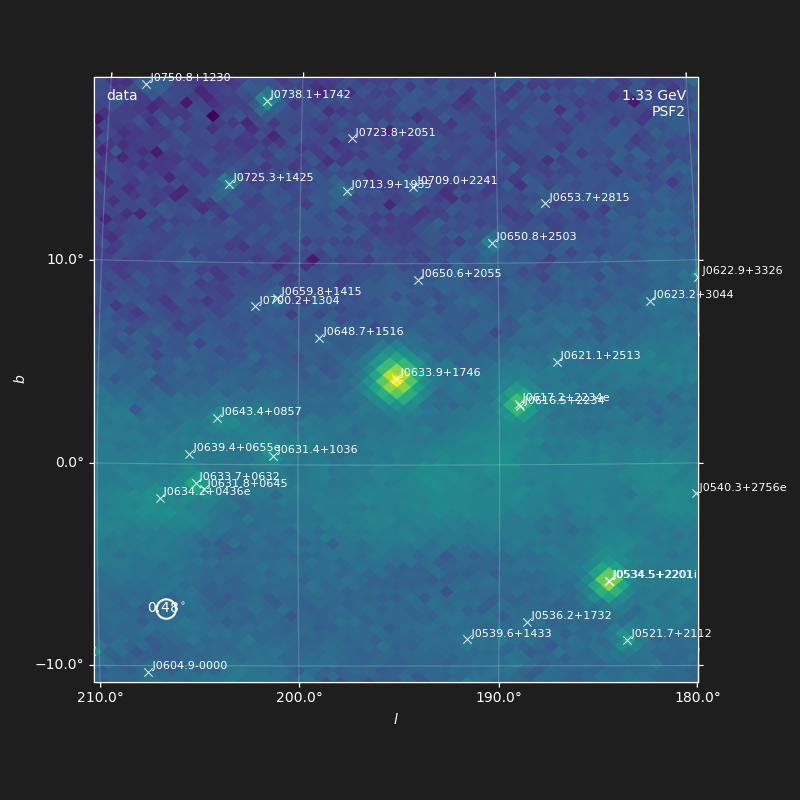

In [3]:
pt[2,4].zea_plot('geminga', 'data', size=30, figsize=(8,8), 
                 catalog=DataFrameCatalog(fgl.query('significance>15')),
                 colorbar=False,
                 ).apply(lambda z: z.ax.grid(alpha=0.2)).show()


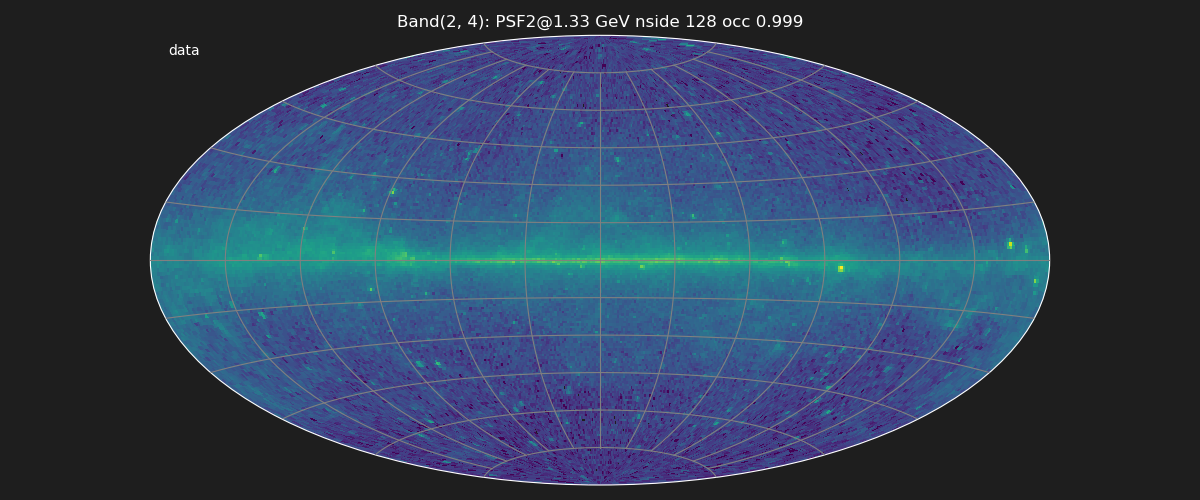

In [4]:
b = pt[2,4]
fig = b.ait_plot(
    'data',
    title=str(b),
    figsize=(12,5),
    colorbar=False, #shrink=0.5,
    value_format='{:.3e}',
    # catalog=DataFrameCatalog(fgl.query('significance>15'))
)
fig.show()

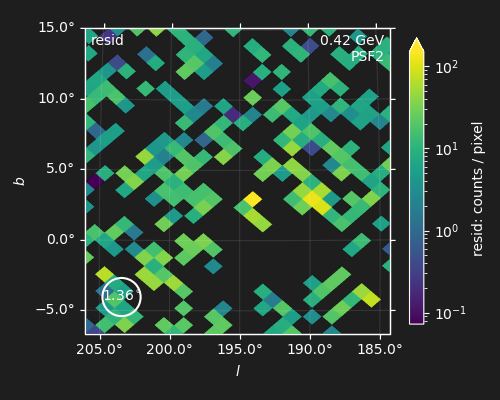

In [5]:
pt[2,2].zea_plot('geminga', 'resid').apply(lambda z: z.ax.grid(alpha=0.1)).show()


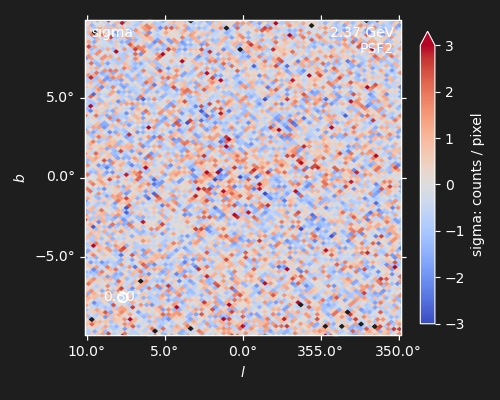

In [6]:
pixel_table[2,5].zea_plot((0,0), 'sigma', log=False, cmap='coolwarm', vmin=-3,vmax=3,size=20).apply(lambda z: z.ax.grid(alpha=0.1)).show()

## Try to make picture of nside=12 

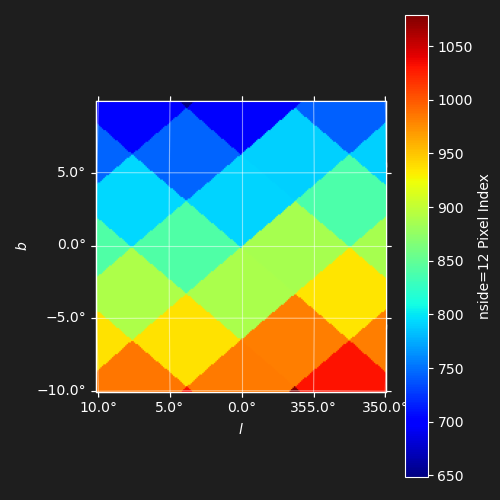

In [7]:
import healpy
from utilities.skymaps import AITfigure, ZEAfigure
nside=12 
a, b = healpy.pix2ang(nside=nside, ipix=range(12*nside*nside), lonlat=True)
pix12= healpy.ang2pix(nside=12, theta=a, phi=b, lonlat=True)
ZEAfigure((0,0), size=20).imshow(pix12).colorbar(label='nside=12 Pixel Index').show()

In [8]:
a, b, pix12

(array([ 45., 135., 225., ..., 135., 225., 315.], shape=(1728,)),
 array([ 86.10076358,  86.10076358,  86.10076358, ..., -86.10076358,
        -86.10076358, -86.10076358], shape=(1728,)),
 array([   0,    1,    2, ..., 1725, 1726, 1727], shape=(1728,)))

In [9]:
pix12[:40]

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39])

In [10]:
healpy.pix2ang(nside=12, ipix=range(12**3), lonlat=True)

(array([ 45., 135., 225., ..., 135., 225., 315.], shape=(1728,)),
 array([ 86.10076358,  86.10076358,  86.10076358, ..., -86.10076358,
        -86.10076358, -86.10076358], shape=(1728,)))